In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("../data/processed/tcs_stock_data_cleaned.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2018-01-01,1341.150024,1347.400024,1317.500000,1322.800049,1351760
2018-01-02,1330.000000,1334.800049,1310.099976,1315.599976,1920290
2018-01-03,1316.000000,1334.500000,1315.599976,1319.324951,1257120
2018-01-04,1325.000000,1331.000000,1320.000000,1328.550049,913082
2018-01-05,1325.000000,1349.750000,1325.000000,1344.599976,1153706


In [3]:
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

train_close = train["Close"]
test_close = test["Close"]

In [4]:
result = adfuller(train_close)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.5438143642134932
p-value: 0.5117365011477522


In [5]:
train_diff = train_close.diff().dropna()

In [6]:
result = adfuller(train_diff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -29.371972805215457
p-value: 0.0


#### (p, d, q)

In [11]:
train_close.index = pd.to_datetime(train_close.index)

train_close = train_close.asfreq('B')   # B = Business days (stock market)

model = ARIMA(train_close, order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1673
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -8103.594
Date:                Sat, 07 Mar 2026   AIC                          16219.188
Time:                        20:44:18   BIC                          16251.718
Sample:                    01-01-2018   HQIC                         16231.241
                         - 05-29-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0177      0.023     -0.776      0.437      -0.062       0.027
ar.L2         -0.0444      0.022     -2.040      0.041      -0.087      -0.002
ar.L3         -0.0151      0.023     -0.660      0.5

In [12]:
print(train_close.index.freq)

<BusinessDay>


In [13]:
forecast = model_fit.forecast(steps=len(test_close))

In [9]:
forecast = pd.Series(forecast, index=test_close.index)

In [14]:
mae = mean_absolute_error(test_close, forecast)
print("MAE:", mae)

MAE: 459.7416681346083


In [15]:
rmse = np.sqrt(mean_squared_error(test_close, forecast))
print("RMSE:", rmse)

RMSE: 510.1652197415475


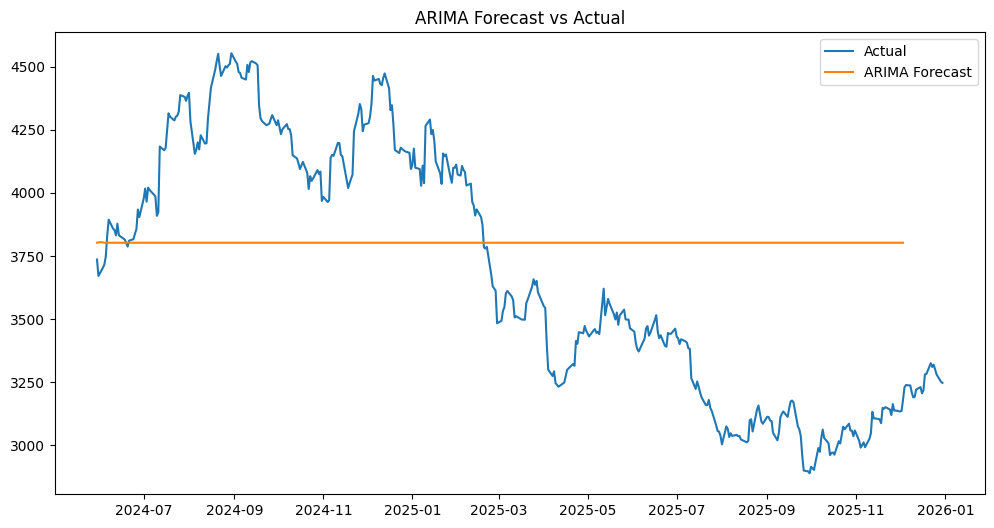

In [16]:
plt.figure(figsize=(12,6))

plt.plot(test_close, label="Actual")
plt.plot(forecast, label="ARIMA Forecast")

plt.title("ARIMA Forecast vs Actual")

plt.legend()

plt.show()

In [17]:
results = pd.DataFrame({
    "Actual": test_close,
    "ARIMA_Prediction": forecast
})

results.to_csv("../data/processed/arima_predictions.csv")

In [18]:
from pmdarima import auto_arima

In [19]:
import pandas as pd

df = pd.read_csv("../data/processed/tcs_stock_data_cleaned.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

close_prices = df["Close"]

In [20]:
split_index = int(len(close_prices) * 0.8)

train = close_prices[:split_index]
test = close_prices[split_index:]

In [21]:
auto_model = auto_arima(
    train,
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    d=1,
    seasonal=False,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16240.546, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16242.276, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16242.252, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16240.822, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16241.355, Time=0.86 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 1.214 seconds


In [22]:
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1580
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8118.273
Date:                Sat, 07 Mar 2026   AIC                          16240.546
Time:                        20:47:57   BIC                          16251.275
Sample:                             0   HQIC                         16244.533
                               - 1580                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.5712      1.044      1.506      0.132      -0.474       3.617
sigma2      1711.1584     38.579     44.354      0.000    1635.544    1786.773
Ljung-Box (L1) (Q):                   0.27   Jarque-

In [26]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

train.index = pd.to_datetime(train.index)
train = train.asfreq('B')
train = train.ffill()   # Business day frequency for stock data

model = ARIMA(train, order=auto_model.order)
model_fit = model.fit()

In [27]:
print(train.index.freq)

<BusinessDay>


In [28]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=auto_model.order)

model_fit = model.fit()

In [37]:
print("NaN in test:\n", test.isna().sum())
print("NaN in forecast:\n", pd.Series(forecast).isna().sum())
print("test length:", len(test))
print("forecast length:", len(forecast))

NaN in test:
 0
NaN in forecast:
 19
test length: 395
forecast length: 395


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

forecast = model_fit.forecast(steps=len(test))
forecast = pd.Series(np.array(forecast).ravel(), index=test.index)
actual = pd.Series(np.array(test).ravel(), index=test.index)

mae = mean_absolute_error(actual, forecast)
rmse = np.sqrt(mean_squared_error(actual, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 459.8628992780854
RMSE: 510.43245588317524


In [46]:
print("NaN in forecast:", pd.Series(forecast).isna().sum())
print("test length:", len(test))
print("forecast length:", len(forecast))
print(test.index.equals(forecast.index))

NaN in forecast: 0
test length: 395
forecast length: 395
True


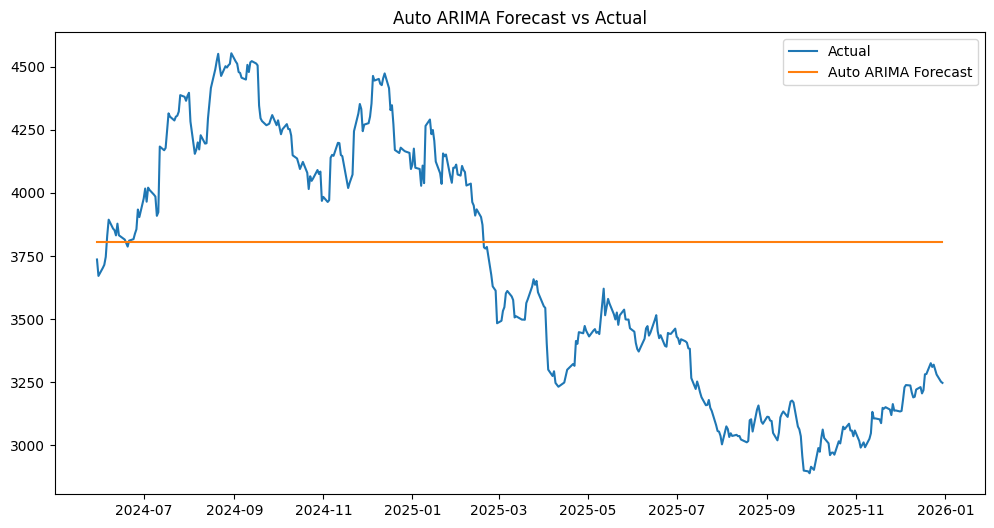

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(test, label="Actual")
plt.plot(forecast, label="Auto ARIMA Forecast")

plt.title("Auto ARIMA Forecast vs Actual")

plt.legend()

plt.show()

In [49]:
results = pd.DataFrame({
    "Actual": test,
    "Auto_ARIMA_Prediction": forecast
})

results.to_csv("../data/processed/auto_arima_predictions.csv")